In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


EDA


In [3]:
data.shape

(1338, 7)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


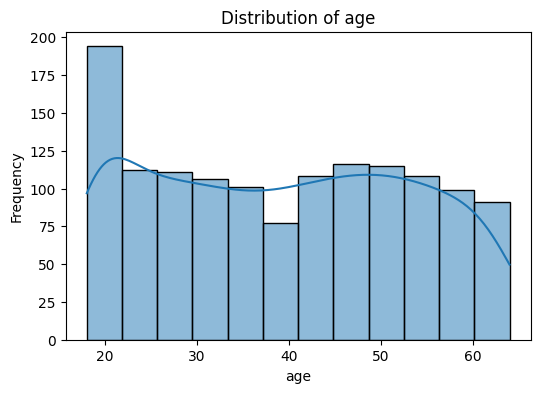

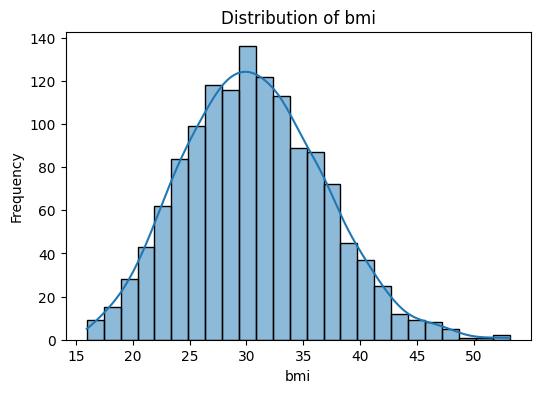

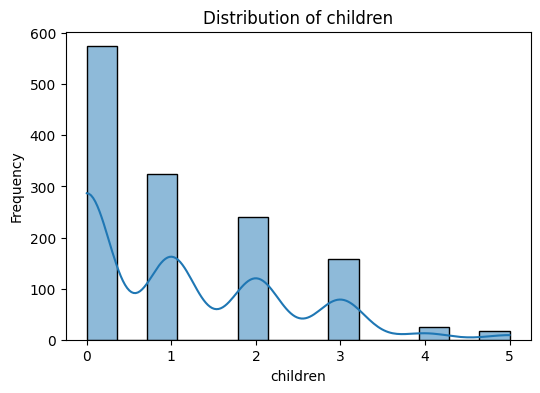

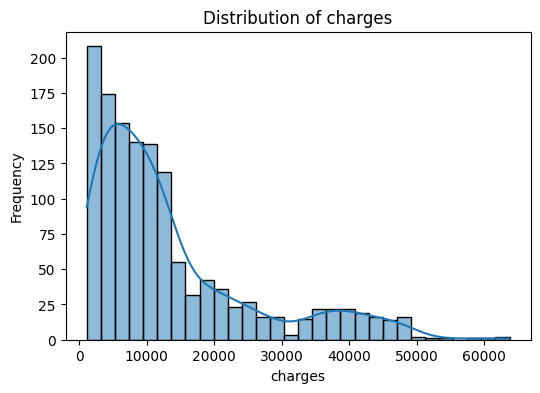

In [10]:
numeric_columns = data.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    

<Axes: xlabel='children', ylabel='count'>

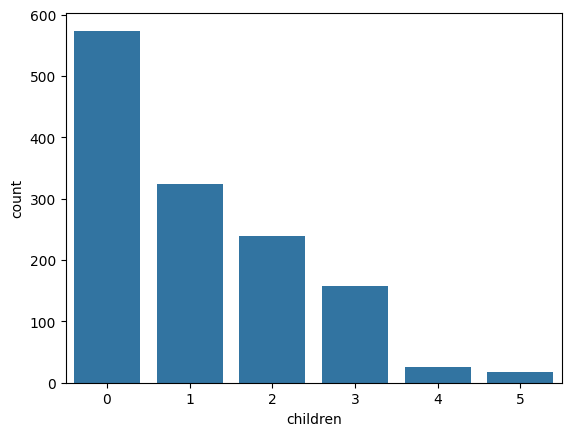

In [11]:
sns.countplot(x='children', data=data)

<Axes: xlabel='smoker', ylabel='count'>

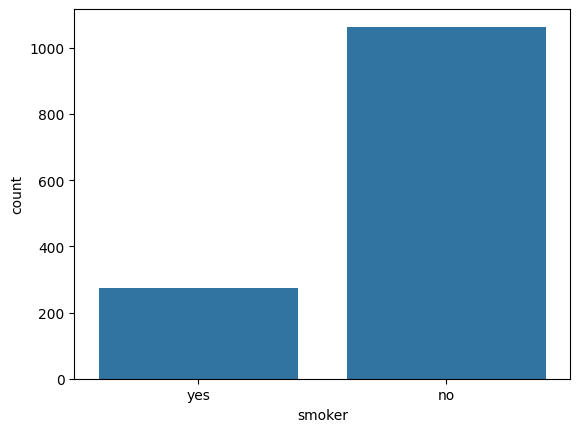

In [12]:
sns.countplot(x='smoker', data=data)

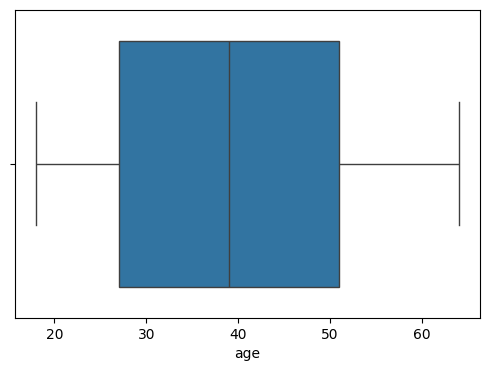

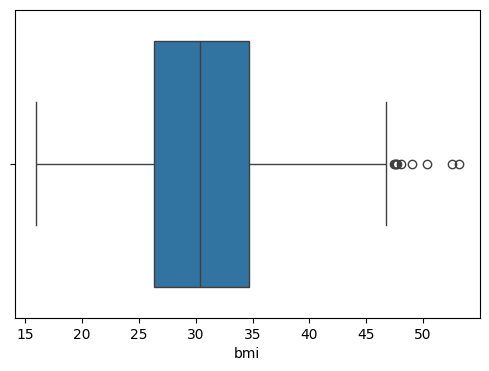

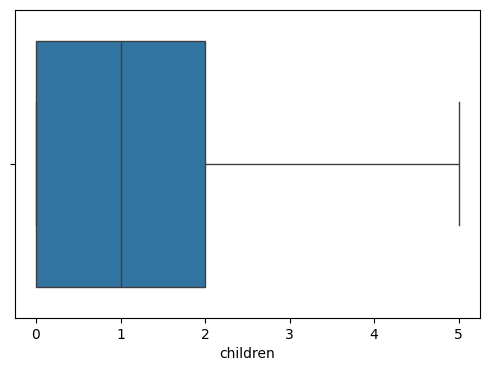

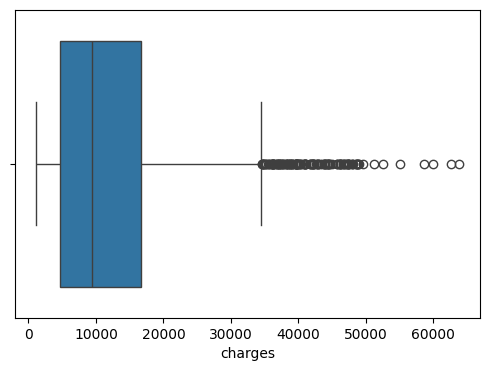

In [13]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    

In [14]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Axes: >

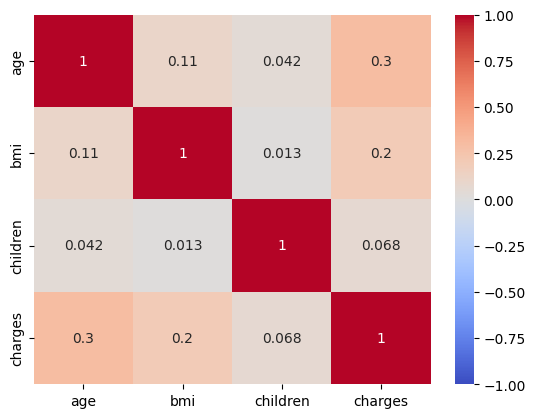

In [15]:
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

#DATA CLEANING AND PREPROCESSING


In [12]:
data_clean = data.copy()

In [13]:
data_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
data_clean.shape

(1338, 7)

In [15]:
data_clean.shape
data_clean.drop_duplicates(inplace=True)
data_clean.shape


(1337, 7)

In [16]:
data_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [17]:
data_clean['sex']=data_clean['sex'].map({'male':0, 'female':1})
data_clean['smoker']=data_clean['smoker'].map({'yes':1, 'no':0})
data_clean['region']=data_clean['region'].map({'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3})
data_clean.head()
data_clean.info()
data_clean.describe()



<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   int64  
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   int64  
 5   region    1337 non-null   int64  
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 83.6 KB


,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,0.495138,30.663452,1.095737,0.204936,1.483919,13279.121487
std,14.044333,0.500163,6.100468,1.205571,0.403806,1.105208,12110.359656
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.290000,0.000000,0.000000,1.000000,4746.344000
50%,39.000000,0.000000,30.400000,1.000000,0.000000,1.000000,9386.161300
75%,51.000000,1.000000,34.700000,2.000000,0.000000,2.000000,16657.717450
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


In [18]:
if 'region' in data_clean.columns:
    data_clean = pd.get_dummies(data_clean, columns=['region'], drop_first=True, dtype=int)
    data_clean = data_clean.rename(columns={
        'region_1': 'region1',
        'region_2': 'region2',
        'region_3': 'region3',
    })

data_clean.head()

,age,sex,bmi,children,smoker,charges,region1,region2,region3
0,19,1,27.900,0,1,16884.92400,0,0,0
1,18,0,33.770,1,0,1725.55230,1,0,0
2,28,0,33.000,3,0,4449.46200,1,0,0
3,33,0,22.705,0,0,21984.47061,0,1,0
4,32,0,28.880,0,0,3866.85520,0,1,0


In [19]:
data_clean.head()

,age,sex,bmi,children,smoker,charges,region1,region2,region3
0,19,1,27.900,0,1,16884.92400,0,0,0
1,18,0,33.770,1,0,1725.55230,1,0,0
2,28,0,33.000,3,0,4449.46200,1,0,0
3,33,0,22.705,0,0,21984.47061,0,1,0
4,32,0,28.880,0,0,3866.85520,0,1,0


In [20]:
for col in ['region1', 'region2', 'region3']:
    if col in data_clean.columns:
        data_clean[col] = data_clean[col].astype(int)

data_clean.head()





,age,sex,bmi,children,smoker,charges,region1,region2,region3
0,19,1,27.900,0,1,16884.92400,0,0,0
1,18,0,33.770,1,0,1725.55230,1,0,0
2,28,0,33.000,3,0,4449.46200,1,0,0
3,33,0,22.705,0,0,21984.47061,0,1,0
4,32,0,28.880,0,0,3866.85520,0,1,0


##feature engineering and extraction


In [31]:
data_clean = data_clean.rename(columns={
    'region_1': 'region1',
    'region_2': 'region2',
    'region_3': 'region3',
})
for col in ['region1', 'region2', 'region3']:
    if col in data_clean.columns:
        data_clean[col] = data_clean[col].astype(int)

bmi_cols = ['underweight', 'normal', 'overweight', 'obese', 'extremely_obese']
data_clean = data_clean.drop(columns=[c for c in bmi_cols + ['bmi_category'] if c in data_clean.columns])

data_clean['bmi_category'] = pd.cut(
    data_clean['bmi'],
    bins=[0, 18.5, 24.9, 29.9, 34.9, np.inf],
    labels=bmi_cols
)
data_clean = pd.get_dummies(data_clean, columns=['bmi_category'], prefix='', prefix_sep='', dtype=int)

data_clean.head()


,age,sex,bmi,children,smoker,charges,region1,region2,region3,underweight,normal,overweight,obese,extremely_obese
0,19,1,27.900,0,1,16884.92400,0,0,0,0,0,1,0,0
1,18,0,33.770,1,0,1725.55230,1,0,0,0,0,0,1,0
2,28,0,33.000,3,0,4449.46200,1,0,0,0,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0,1,0,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,1,0,0


In [33]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children',]
scaler=StandardScaler()
data_clean[cols]=scaler.fit_transform(data_clean[cols])
data_clean.head()




,age,sex,bmi,children,smoker,charges,region1,region2,region3,bmi_category
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0,0,2
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,1,0,0,3
2,-0.799350,0,0.383155,1.580143,0,4449.46200,1,0,0,3
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,0,1,0,1
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,0,1,0,2


In [34]:
from scipy.stats import pearsonr

selected_features = [
    'age', 'bmi', 'children', 'smoker', 'sex',
    'region1', 'region2', 'region3',
    'underweight', 'normal', 'overweight', 'obese', 'extremely_obese',
]

correlation = {
    feature: pearsonr(data_clean[feature], data_clean['charges'])[0]
    for feature in selected_features
}

correlation_data = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Correlation'])
correlation_data = correlation_data.sort_values(by='Correlation', ascending=False)
correlation_data




Feature,Correlation
smoker,0.787234
age,0.298308
bmi,0.198401
extremely_obese,0.175616
region1,0.073578
children,0.067389
obese,0.051993
region3,0.005945
region2,-0.038695
underweight,-0.048225


In [39]:
from scipy.stats import chi2_contingency

cat_features = [
    'smoker', 'sex',
    'region1', 'region2', 'region3',
    'underweight', 'normal', 'overweight', 'obese', 'extremely_obese',
]

alpha = 0.05
data_clean['charges_bin'] = pd.qcut(data_clean['charges'], q=4, labels=False)

chi2_results = {}
for feature in cat_features:
    contingency_table = pd.crosstab(data_clean[feature], data_clean['charges_bin'])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    decision = 'Reject Null (Keep Feature)' if p_value < alpha else 'Fail to Reject Null (Remove Feature)'
    chi2_results[feature] = (chi2_stat, p_value, decision)

chi2_data = pd.DataFrame.from_dict(
    chi2_results, orient='index', columns=['chi2', 'p_value', 'decision']
)
chi2_data = chi2_data.sort_values(by='p_value', ascending=True)
chi2_data


,chi2,p_value,decision
smoker,848.219178,1.507478e-183,Reject Null (Keep Feature)
region1,15.998167,1.134966e-03,Reject Null (Keep Feature)
sex,10.258784,1.648974e-02,Reject Null (Keep Feature)
extremely_obese,9.907686,1.936736e-02,Reject Null (Keep Feature)
region3,6.438442,9.212206e-02,Fail to Reject Null (Remove Feature)
underweight,4.384749,2.228037e-01,Fail to Reject Null (Remove Feature)
normal,4.263673,2.343638e-01,Fail to Reject Null (Remove Feature)
overweight,4.201575,2.405042e-01,Fail to Reject Null (Remove Feature)
region2,1.134240,7.688154e-01,Fail to Reject Null (Remove Feature)
obese,0.087118,9.933372e-01,Fail to Reject Null (Remove Feature)


In [46]:
# Keep predictors that are meaningfully related to charges (|r| >= 0.15).
# From Pearson: smoker ~0.79, age ~0.30, bmi ~0.20, extremely_obese ~0.18
drop_cols = {'charges_bin'}
corr_with_charges = (
    data_clean.drop(columns=[c for c in drop_cols if c in data_clean.columns], errors='ignore')
    .corr(numeric_only=True)['charges']
    .abs()
    .sort_values(ascending=False)
)
keep_cols = [c for c in corr_with_charges.index if corr_with_charges[c] >= 0.15]
final_data = data_clean[keep_cols]
display(corr_with_charges.to_frame('abs_correlation'))
final_data.head()


,abs_correlation
charges,1.000000
smoker,0.787234
age,0.298308
bmi_category,0.209867
bmi,0.198401
region1,0.073578
children,0.067389
sex,0.058044
region2,0.038695
region3,0.005945


,charges,smoker,age,bmi_category,bmi
0,16884.92400,1,-1.440418,2,-0.453160
1,1725.55230,0,-1.511647,3,0.509422
2,4449.46200,0,-0.799350,3,0.383155
3,21984.47061,0,-0.443201,1,-1.305052
4,3866.85520,0,-0.514431,2,-0.292456
